# Designing the lens system to collimate a beam after an optical fiber

The Optical fiber information we have is:
- Customer: AMS Technologies AG
- Part QPMJ-A3A, 3S-400-3/125-3-2-1
- Fiber Core/Cladding/Jacket Diameter (in micron): 3/125/3000
- Numerical Aperture (NA): 0.11
- Length (m): 1x (2 $\pm$ 0.1) and 3x (5 $\pm$ 0.1)
- Fiber Type: QP, Single Mode, Polarization Maintaining
- Wavelength (nm): 405

Using solely the NA to predict the beam propagation can lead to great inaccuracies, as seen at the [Thorlabs Insights](https://www.thorlabs.com/numerical-aperture-is-not-a-good-parameter-for-single-mode-fibers?tabName=Insights).

A better option is to use the mode field diameter (MFD) as the Gaussion beam diameter at the waist.
Therefore, we have to compute the MFD which can be approximated for a single-mode fiber as,
$$MFD = \frac{2 \lambda}{\pi \cdot NA}$$
following [Schafter+Kirchhoff MFD computation](https://www.sukhamburg.com/support/technotes/fiberoptics/cablebasics/mfd.html), thus considering the MFD and NA for a 1/$e^2$ of a Gaussian beam.

## Gaussian Beam Equations
The Gaussian beam propagation can be described using the following equations:
- Beam waist ($w_0$):
$$w_0 = \frac{MFD}{2}$$
- Far-field divergence angle ($\theta$):
$$\theta = \frac{\lambda}{\pi \cdot w_0}$$
- Beam radius at distance $z$ from the waist ($w(z)$):
$$w(z) = w_0 \sqrt{1 + \left(\frac{z}{z_R}\right)^2}$$
where $z_R$ is the Rayleigh range, given by:
$$z_R = \frac{\pi w_0^2}{\lambda}$$

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, FloatText
%matplotlib inline

In [25]:
def simulate_beam_propagation(wavelength_nm=405.0, NA=0.11, target_radius_mm=6.5, z_max_mm=100.0):
    """
    Simulate Gaussian beam propagation and find z for target radius.
    All calculations in mm.
    """
    # Convert wavelength to mm
    wavelength = wavelength_nm / 1e6
    
    # Calculate MFD in mm
    MFD = (2 * wavelength) / (np.pi * NA)
    
    # Calculate beam waist w0 in mm
    w0 = MFD / 2
    
    # Calculate Rayleigh range in mm
    z_R = (np.pi * w0**2) / wavelength
    
    # Calculate far-field divergence angle in radians
    theta = wavelength / (np.pi * w0)
    
    # Create z array in mm
    z = np.linspace(0, z_max_mm, 1000)
    
    # Calculate beam radius at each z in mm
    w_z = w0 * np.sqrt(1 + (z / z_R)**2)
    
    # Calculate z for target radius
    if target_radius_mm > w0:
        z_target = z_R * np.sqrt((target_radius_mm / w0)**2 - 1)
    else:
        z_target = 0.0
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot w(z)
    ax1.plot(z, w_z, 'b-', linewidth=2)
    ax1.axhline(w0, color='r', linestyle='--', label=f'Beam waist $w_0$ = {w0*1e3:.3f} \u03bcm')
    ax1.axvline(z_R, color='g', linestyle='--', label=f'Rayleigh range $z_R$ = {z_R:.3f} mm')
    ax1.axhline(target_radius_mm, color='k', linestyle=':', label=f'Target radius = {target_radius_mm:.3f} mm')
    ax1.axvline(z_target, color='k', linestyle=':', label=f'z for target = {z_target:.3f} mm')
    ax1.set_xlabel('Distance z (mm)')
    ax1.set_ylabel('Beam radius w(z) (mm)')
    ax1.set_title('Gaussian Beam Propagation')
    ax1.legend()
    ax1.grid(True)
    
    # Plot w(z) in log scale for better visualization of divergence
    ax2.plot(z, w_z, 'b-', linewidth=2)
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_xlabel('Distance z (mm) - log scale')
    ax2.set_ylabel('Beam radius w(z) (mm) - log scale')
    ax2.set_title('Gaussian Beam Propagation (log-log)')
    ax2.grid(True, which='both')
    
    plt.tight_layout()
    plt.show()
    
    # Print parameters
    print(f'Wavelength: {wavelength_nm} nm ({wavelength*1e3:.6f} \u03bcm)')
    print(f'Numerical Aperture: {NA}')
    print(f'MFD: {MFD*1e3:.3f} \u03bcm')
    print(f'Beam waist w0: {w0*1e3:.3f} \u03bcm')
    print(f'Rayleigh range z_R: {z_R:.3f} mm')
    print(f'Far-field divergence angle: {np.degrees(theta):.6f} degrees ({theta*1e3:.6f} mrad)')
    print(f'\nDistance z to achieve radius w = {target_radius_mm:.3f} mm:')
    print(f'  z = {z_target:.6f} mm')
    
    return z_target

In [26]:
# Create interactive sliders
interact(
    simulate_beam_propagation,
    wavelength_nm=FloatSlider(min=390, max=450, step=1, value=423, description='Wavelength (nm):', style={'description_width': 'initial'}),
    NA=FloatSlider(min=0.01, max=0.3, step=0.01, value=0.11, description='NA:', style={'description_width': 'initial'}),
    target_radius_mm=FloatSlider(min=4, max=20, step=0.1, value=6.5, description='Target radius (mm):', style={'description_width': 'initial'}),
    z_max_mm=FloatSlider(min=10, max=200, step=10, value=100, description='Max z (mm):', style={'description_width': 'initial'})
)

interactive(children=(FloatSlider(value=423.0, description='Wavelength (nm):', max=450.0, min=390.0, step=1.0,…

<function __main__.simulate_beam_propagation(wavelength_nm=405.0, NA=0.11, target_radius_mm=6.5, z_max_mm=100.0)>

## Explanation

The interactive simulation above allows you to:
- Adjust the **wavelength**
- Adjust the **Numerical Aperture**
- Set a **target beam radius**
- Set the **maximum z range**

The left plot shows the beam radius as a function of distance from the waist in linear scale.
The right plot shows the same in log-log scale, which is useful for visualizing the far-field divergence.

The calculation prints:
- The computed MFD (Mode Field Diameter)
- The beam waist w0 = MFD/2
- The Rayleigh range z_R
- The far-field divergence angle
- The distance z required to achieve the target beam radius

**Note:** This notebook uses `%matplotlib inline` for compatibility. For interactive plots that update with the sliders, install `ipympl`:
```
pip install ipympl
```
Then change `%matplotlib inline` to `%matplotlib widget` in the imports cell and restart the kernel.

All printed values are in mm (or micrometers for wavelength), and the target radius calculation uses the formula:
$$z = z_R \sqrt{\left(\frac{w}{w_0}\right)^2 - 1}$$

## Lens System Collimator Design

This section designs a two-lens collimation system with:
- A **divergent lens** (negative focal length - expands the beam)
- A **convergent lens** (positive focal length - collimates the beam)

Given the focal lengths of both lenses and the distance from the beam waist to the convergent lens, it calculates the optimal position for the divergent lens to achieve beam collimation (approximately constant beam radius after the convergent lens).

The calculation uses Gaussian beam optics with the q-parameter formalism to propagate the beam through the lens system and find the lens position that minimizes beam divergence after the convergent lens.

In [27]:
def design_lens_collimator(wavelength_nm=405.0, NA=0.11, f_divergent_mm=-20.0, f_convergent_mm=50.0, target_radius_mm=6.5):
    """Design a two-lens system with a collimated output waist of target_radius_mm."""
    from scipy.optimize import brentq

    if wavelength_nm <= 0 or NA <= 0 or target_radius_mm <= 0:
        raise ValueError('wavelength_nm, NA, and target_radius_mm must be positive.')
    if f_divergent_mm >= 0 or f_convergent_mm <= 0:
        raise ValueError('Use a negative divergent focal length and a positive convergent focal length.')

    wavelength = wavelength_nm / 1e6
    MFD = 2 * wavelength / (np.pi * NA)
    w0 = MFD / 2
    z_R = np.pi * w0**2 / wavelength
    theta_0 = wavelength / (np.pi * w0)
    target_z_R = np.pi * target_radius_mm**2 / wavelength

    def beam_radius_from_q(q):
        if not isinstance(q, complex) or q.imag <= 0:
            return np.nan
        return np.sqrt(wavelength / np.pi * (q.imag + q.real**2 / q.imag))

    def q_after_divergent_lens(d1):
        q_before = 1j * z_R + d1
        return 1 / (1 / q_before - 1 / f_divergent_mm)

    q_before_convergent = 1 / (1 / f_convergent_mm - 1j / target_z_R)
    required_imag = q_before_convergent.imag

    def imag_error(d1):
        return q_after_divergent_lens(d1).imag - required_imag

    search_max = 5000.0
    sample_points = np.linspace(0.0, search_max, 2001)
    roots = []
    for left, right in zip(sample_points[:-1], sample_points[1:]):
        if imag_error(left) == 0:
            roots.append(left)
        elif imag_error(left) * imag_error(right) < 0:
            roots.append(brentq(imag_error, left, right))

    candidates = []
    for d1 in roots:
        q_div = q_after_divergent_lens(d1)
        separation = q_before_convergent.real - q_div.real
        if separation > 1e-9:
            candidates.append((d1, separation))

    if not candidates:
        raise ValueError(
            f'No physical solution for target radius {target_radius_mm:.3f} mm with these focal lengths. '
            f'Try a larger target radius or different focal lengths. '
            f'The requested output waist Rayleigh range is {target_z_R:.3f} mm.'
        )

    optimal_d1, separation = min(candidates, key=lambda candidate: candidate[0])
    optimal_D = optimal_d1 + separation
    q4 = 1 / (1 / q_before_convergent - 1 / f_convergent_mm)
    w_out = beam_radius_from_q(q4)

    print('Beam parameters:')
    print(f'  Wavelength: {wavelength_nm} nm')
    print(f'  NA: {NA}')
    print(f'  Initial waist radius: {w0 * 1e3:.6f} um')
    print(f'  Initial Rayleigh range: {z_R:.6f} mm')
    print(f'  Initial divergence: {np.degrees(theta_0):.6f} deg')
    print()
    print('Optimized lens positions:')
    print(f'  Divergent lens at: {optimal_d1:.6f} mm from initial waist')
    print(f'  Convergent lens at: {optimal_D:.6f} mm from initial waist')
    print(f'  Distance between lenses: {separation:.6f} mm')
    print()
    print('Output beam parameters:')
    print(f'  Output waist radius: {w_out:.9f} mm')
    print(f'  Radius error: {abs(w_out - target_radius_mm) * 1e6:.3f} nm')
    print(f'  Wavefront curvature error Re(q_out): {abs(q4.real):.3e} mm')
    print(f'  Output divergence: {np.degrees(wavelength / (np.pi * w_out)):.9f} deg')

    def beam_radius_at_z(z):
        q0 = 1j * z_R
        if z <= optimal_d1:
            q = q0 + z
        elif z <= optimal_D:
            q = q_after_divergent_lens(optimal_d1) + (z - optimal_d1)
        else:
            q = q4 + (z - optimal_D)
        return beam_radius_from_q(q)

    z1 = np.linspace(0, optimal_d1, 300)
    z2 = np.linspace(optimal_d1, optimal_D, 300)
    z3 = np.linspace(optimal_D, optimal_D + 100, 300)
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.plot(z1, [beam_radius_at_z(z) for z in z1], 'b-', linewidth=2, label='Before divergent lens')
    ax.plot(z2, [beam_radius_at_z(z) for z in z2], 'g-', linewidth=2, label='Between lenses')
    ax.plot(z3, [beam_radius_at_z(z) for z in z3], 'r-', linewidth=2, label='After convergent lens')
    ax.axvline(optimal_d1, color='k', linestyle='--', label=f'Divergent lens at {optimal_d1:.2f} mm')
    ax.axvline(optimal_D, color='m', linestyle='--', label=f'Convergent lens at {optimal_D:.2f} mm')
    ax.axhline(target_radius_mm, color='k', linestyle=':', label=f'Target: {target_radius_mm:.3f} mm')
    ax.set_xlabel('Distance from initial waist (mm)')
    ax.set_ylabel('Beam radius (mm)')
    ax.set_title('Beam Propagation Through Optimized Lens System')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    return optimal_d1, optimal_D

In [28]:
# Create interactive sliders for the lens system design
interact(
    design_lens_collimator,
    wavelength_nm=FloatSlider(min=390, max=450, step=1, value=423, description='Wavelength (nm):', style={'description_width': 'initial'}),
    NA=FloatSlider(min=0.01, max=0.3, step=0.01, value=0.11, description='NA:', style={'description_width': 'initial'}),
    f_divergent_mm=FloatSlider(min=-500, max=-5, step=1, value=-100, description='Divergent focal (mm):', style={'description_width': 'initial'}),
    f_convergent_mm=FloatSlider(min=10, max=100, step=1, value=50, description='Convergent focal (mm):', style={'description_width': 'initial'}),
    target_radius_mm=FloatSlider(min=0.1, max=10, step=0.1, value=6.5, description='Target radius (mm):', style={'description_width': 'initial'})
)

interactive(children=(FloatSlider(value=423.0, description='Wavelength (nm):', max=450.0, min=390.0, step=1.0,…

<function __main__.design_lens_collimator(wavelength_nm=405.0, NA=0.11, f_divergent_mm=-20.0, f_convergent_mm=50.0, target_radius_mm=6.5)>

In [29]:
def scan_collimated_beams(
    wavelength_nm=423.0,
    NA=0.11,
    f_divergent_mm=-100.0,
    f_convergent_mm=50.0,
    divergent_min_mm=15.0,
    divergent_max_mm=30.0,
    samples=100,
):
    """Compute collimated radius and convergent-lens position over a d_div range."""
    if wavelength_nm <= 0 or NA <= 0:
        raise ValueError('wavelength_nm and NA must be positive.')
    if f_divergent_mm >= 0 or f_convergent_mm <= 0:
        raise ValueError('Use a negative divergent focal length and a positive convergent focal length.')
    if divergent_min_mm < 0 or divergent_max_mm <= divergent_min_mm:
        raise ValueError('Use a valid divergent-lens distance range.')

    wavelength = wavelength_nm / 1e6
    w0 = wavelength / (np.pi * NA)
    z_R = np.pi * w0**2 / wavelength

    def q_after_divergent_lens(d_div):
        q_before = 1j * z_R + d_div
        return 1 / (1 / q_before - 1 / f_divergent_mm)

    results = []
    d_div_values = np.linspace(divergent_min_mm, divergent_max_mm, samples)
    for d_div in d_div_values:
        q_div = q_after_divergent_lens(d_div)
        x_div, y_div = q_div.real, q_div.imag
        discriminant = f_convergent_mm**2 - 4 * y_div**2
        if discriminant < 0:
            continue

        for x_before_conv in (
            (f_convergent_mm - np.sqrt(max(0.0, discriminant))) / 2,
            (f_convergent_mm + np.sqrt(max(0.0, discriminant))) / 2,
        ):
            lens_separation = x_before_conv - x_div
            if lens_separation <= 0:
                continue
            d_conv = d_div + lens_separation
            q_before_conv = x_before_conv + 1j * y_div
            q_out = 1 / (1 / q_before_conv - 1 / f_convergent_mm)
            collimated_radius = np.sqrt(wavelength * q_out.imag / np.pi)
            results.append({
                'd_div_mm': d_div,
                'd_conv_mm': d_conv,
                'collimated_radius_mm': collimated_radius,
                'output_divergence_mrad': wavelength / (np.pi * collimated_radius) * 1e3,
                'wavefront_error_mm': abs(q_out.real),
            })

    print(f'f_divergent = {f_divergent_mm:.3f} mm')
    print(f'f_convergent = {f_convergent_mm:.3f} mm')
    print(f'divergent-lens range = [{divergent_min_mm:.3f}, {divergent_max_mm:.3f}] mm')
    if not results:
        print('No physically valid collimated configurations were found.')
        return results

    results.sort(key=lambda result: (result['d_div_mm'], result['d_conv_mm']))
    print(f'Found {len(results)} collimated configurations:')
    print('d_div (mm) | d_conv (mm) | radius (mm) | divergence (mrad)')
    for result in results:
        print(
            f"{result['d_div_mm']:10.4f} | "
            f"{result['d_conv_mm']:11.4f} | "
            f"{result['collimated_radius_mm']:11.6f} | "
            f"{result['output_divergence_mrad']:17.6f}"
        )

    d_div_plot = [result['d_div_mm'] for result in results]
    d_conv_plot = [result['d_conv_mm'] for result in results]
    radius_plot = [result['collimated_radius_mm'] for result in results]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(d_div_plot, d_conv_plot, 'o-')
    ax1.set_xlabel('Divergent-lens position d_div (mm)')
    ax1.set_ylabel('Computed convergent-lens position d_conv (mm)')
    ax1.set_title('Collimating lens positions')
    ax1.grid(True)
    ax2.plot(d_div_plot, radius_plot, 'o-')
    ax2.set_xlabel('Divergent-lens position d_div (mm)')
    ax2.set_ylabel('Collimated output radius (mm)')
    ax2.set_title('Possible collimated radii')
    ax2.grid(True)
    plt.tight_layout()
    plt.show()

    return results

f_divergent = -50.000 mm
f_convergent = 50.000 mm
divergent-lens range = [10.000, 30.000] mm
Found 100 collimated configurations:
d_div (mm) | d_conv (mm) | radius (mm) | divergence (mrad)
   10.0000 |     51.6667 |    6.600000 |          0.020401
   10.2020 |     51.7289 |    6.622222 |          0.020332
   10.4040 |     51.7920 |    6.644444 |          0.020264
   10.6061 |     51.8561 |    6.666667 |          0.020197
   10.8081 |     51.9210 |    6.688889 |          0.020130
   11.0101 |     51.9869 |    6.711111 |          0.020063
   11.2121 |     52.0537 |    6.733333 |          0.019997
   11.4141 |     52.1214 |    6.755556 |          0.019931
   11.6162 |     52.1899 |    6.777778 |          0.019866
   11.8182 |     52.2594 |    6.800000 |          0.019801
   12.0202 |     52.3296 |    6.822222 |          0.019736
   12.2222 |     52.4008 |    6.844444 |          0.019672
   12.4242 |     52.4728 |    6.866667 |          0.019609
   12.6263 |     52.5456 |    6.888889 |    

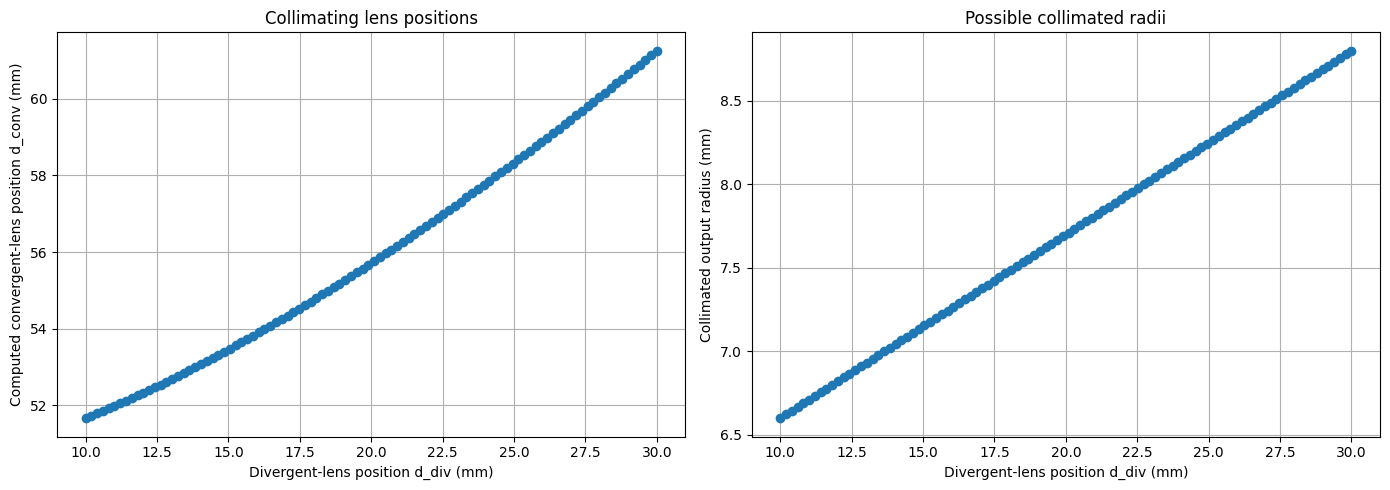

In [37]:
collimated_beams = scan_collimated_beams(
    f_convergent_mm=50.0,
    f_divergent_mm=-50.0,
    divergent_min_mm=10.0,
    divergent_max_mm=30.0,
)

In [31]:
def design_from_collimated_radii(
    collimated_radius_min_mm=6.325,
    collimated_radius_max_mm=7.150,
    wavelength_nm=423.0,
    NA=0.11,
    f_divergent_mm=-100.0,
    f_convergent_mm=50.0,
    radius_samples=20,
    divergent_search_max_mm=5000.0,
):
    """Compute lens positions for a range of collimated output radii."""
    from scipy.optimize import brentq

    if collimated_radius_min_mm <= 0 or collimated_radius_max_mm <= collimated_radius_min_mm:
        raise ValueError('Use a valid positive collimated-radius range.')
    if wavelength_nm <= 0 or NA <= 0:
        raise ValueError('wavelength_nm and NA must be positive.')
    if f_divergent_mm >= 0 or f_convergent_mm <= 0:
        raise ValueError('Use a negative divergent focal length and a positive convergent focal length.')

    wavelength = wavelength_nm / 1e6
    w0 = wavelength / (np.pi * NA)
    z_R = np.pi * w0**2 / wavelength
    radius_values = np.linspace(collimated_radius_min_mm, collimated_radius_max_mm, radius_samples)
    results = []

    def q_after_divergent_lens(d_div):
        q_before = 1j * z_R + d_div
        return 1 / (1 / q_before - 1 / f_divergent_mm)

    for radius in radius_values:
        target_z_R = np.pi * radius**2 / wavelength
        q_before_convergent = 1 / (1 / f_convergent_mm - 1j / target_z_R)

        def imag_error(d_div):
            return q_after_divergent_lens(d_div).imag - q_before_convergent.imag

        search_positions = np.linspace(0.0, divergent_search_max_mm, 2001)
        errors = np.array([imag_error(position) for position in search_positions])
        roots = []
        for index in np.where(errors[:-1] * errors[1:] <= 0)[0]:
            if errors[index] == 0:
                root = search_positions[index]
            else:
                root = brentq(imag_error, search_positions[index], search_positions[index + 1])
            if not roots or abs(root - roots[-1]) > 1e-7:
                roots.append(root)

        for d_div in roots:
            q_div = q_after_divergent_lens(d_div)
            separation = q_before_convergent.real - q_div.real
            if separation <= 0:
                continue
            results.append({
                'collimated_radius_mm': radius,
                'd_div_mm': d_div,
                'd_conv_mm': d_div + separation,
            })

    print(f'Collimated-radius range: [{collimated_radius_min_mm:.4f}, {collimated_radius_max_mm:.4f}] mm')
    print(f'f_divergent={f_divergent_mm:.3f} mm, f_convergent={f_convergent_mm:.3f} mm')
    if not results:
        print('No physical lens positions were found for this radius range.')
        return results

    results.sort(key=lambda result: result['collimated_radius_mm'])
    print('radius (mm) | d_div (mm) | d_conv (mm)')
    for result in results:
        print(
            f"{result['collimated_radius_mm']:11.6f} | "
            f"{result['d_div_mm']:10.6f} | {result['d_conv_mm']:10.6f}"
        )

    radii = [result['collimated_radius_mm'] for result in results]
    divergent_positions = [result['d_div_mm'] for result in results]
    convergent_positions = [result['d_conv_mm'] for result in results]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(radii, divergent_positions, 'o-', label='Divergent lens position')
    ax.plot(radii, convergent_positions, 'o-', label='Convergent lens position')
    ax.set_xlabel('Collimated output radius (mm)')
    ax.set_ylabel('Lens position from initial waist (mm)')
    ax.set_title('Lens positions for requested collimated radii')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()
    return results

Collimated-radius range: [4.0000, 6.0000] mm
f_divergent=-50.000 mm, f_convergent=40.000 mm
radius (mm) | d_div (mm) | d_conv (mm)
   4.421053 |   0.239235 |  40.001134
   4.526316 |   1.435407 |  40.040053
   4.631579 |   2.631579 |  40.131574
   4.736842 |   3.827752 |  40.272191
   4.842105 |   5.023924 |  40.458702
   4.947368 |   6.220096 |  40.688177
   5.052632 |   7.416268 |  40.957931
   5.157895 |   8.612440 |  41.265498
   5.263158 |   9.808613 |  41.608610
   5.368421 |  11.004785 |  41.985174
   5.473684 |  12.200957 |  42.393262
   5.578947 |  13.397129 |  42.831089
   5.684211 |  14.593301 |  43.297003
   5.789474 |  15.789474 |  43.789472
   5.894737 |  16.985646 |  44.307072
   6.000000 |  18.181818 |  44.848483


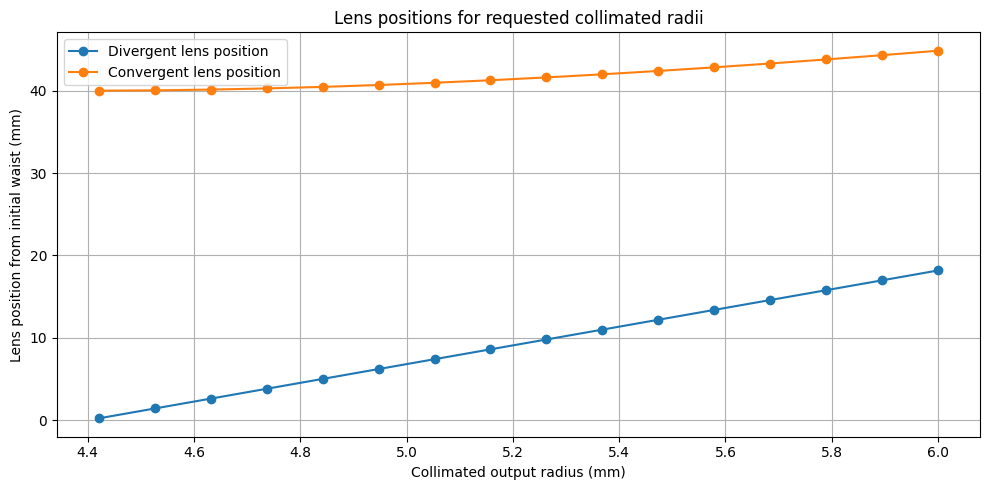

In [61]:
lens_designs_from_radius = design_from_collimated_radii(
    collimated_radius_min_mm=4,
    collimated_radius_max_mm=6,
    f_divergent_mm=-50.0,
    f_convergent_mm=40.0,
)

In [33]:
def design_with_fixed_following_lens(
    collimated_radius_min_mm=6.325,
    collimated_radius_max_mm=7.150,
    wavelength_nm=423.0,
    NA=0.11,
    f_divergent_mm=-100.0,
    f_optimized_convergent_mm=50.0,
    following_lens_focal_length_mm=50.0,
    following_lens_distance_mm=5.0,
    radius_samples=20,
    search_max_mm=5000.0,
):
    """Optimize the complete three-lens system for a collimated final beam."""
    from scipy.optimize import least_squares

    if collimated_radius_min_mm <= 0 or collimated_radius_max_mm <= collimated_radius_min_mm:
        raise ValueError('Use a valid positive collimated-radius range.')
    if wavelength_nm <= 0 or NA <= 0:
        raise ValueError('wavelength_nm and NA must be positive.')
    if f_divergent_mm >= 0 or f_optimized_convergent_mm <= 0:
        raise ValueError('Use a negative divergent focal length and a positive optimized convergent focal length.')
    if following_lens_focal_length_mm <= 0 or following_lens_distance_mm <= 0:
        raise ValueError('The following lens focal length and distance must be positive.')

    wavelength = wavelength_nm / 1e6
    w0 = wavelength / (np.pi * NA)
    z_R = np.pi * w0**2 / wavelength
    radius_values = np.linspace(collimated_radius_min_mm, collimated_radius_max_mm, radius_samples)
    results = []

    def final_q(d_div, lens_separation, target_z_R):
        d_optimized_convergent = d_div + lens_separation
        q = 1j * z_R + d_div
        q = 1 / (1 / q - 1 / f_divergent_mm)
        q = q + lens_separation
        q = 1 / (1 / q - 1 / f_optimized_convergent_mm)
        q = q + following_lens_distance_mm
        q = 1 / (1 / q - 1 / following_lens_focal_length_mm)
        return q, d_optimized_convergent

    for target_radius in radius_values:
        target_z_R = np.pi * target_radius**2 / wavelength

        def residuals(parameters):
            d_div, lens_separation = parameters
            q_out, _ = final_q(d_div, lens_separation, target_z_R)
            return np.array([
                q_out.real / target_z_R,
                (q_out.imag - target_z_R) / target_z_R,
            ])

        starts = []
        for d_div_start in np.linspace(1.0, min(500.0, search_max_mm), 5):
            for separation_start in np.linspace(1.0, 200.0, 5):
                starts.append([d_div_start, separation_start])

        candidates = []
        for start in starts:
            solution = least_squares(
                residuals,
                start,
                bounds=([0.0, 1e-6], [search_max_mm, search_max_mm]),
                max_nfev=3000,
            )
            if np.linalg.norm(solution.fun) < 1e-7:
                d_div, lens_separation = solution.x
                q_out, d_optimized_convergent = final_q(
                    d_div, lens_separation, target_z_R
                )
                candidates.append((d_div, lens_separation, d_optimized_convergent, q_out))

        if not candidates:
            continue

        d_div, lens_separation, d_optimized_convergent, q_out = min(
            candidates, key=lambda candidate: candidate[0]
        )
        d_following_lens = d_optimized_convergent + following_lens_distance_mm
        results.append({
            'final_collimated_radius_mm': target_radius,
            'd_div_mm': d_div,
            'd_optimized_convergent_mm': d_optimized_convergent,
            'd_following_convergent_mm': d_following_lens,
            'final_wavefront_error_mm': abs(q_out.real),
            'final_radius_error_mm': abs(
                np.sqrt(wavelength * q_out.imag / np.pi) - target_radius
            ),
        })

    print(
        f'Optimized focal length: {f_optimized_convergent_mm:.3f} mm; '
        f'fixed following focal length: {following_lens_focal_length_mm:.3f} mm'
    )
    print(f'Following lens offset: {following_lens_distance_mm:.3f} mm')
    if not results:
        print('No complete three-lens solution was found for this radius range.')
        return results

    results.sort(key=lambda result: result['final_collimated_radius_mm'])
    print('final radius | d_div | d_conv(opt.) | d_conv(3rd) | Re(q_final)')
    for result in results:
        print(
            f"{result['final_collimated_radius_mm']:12.6f} | "
            f"{result['d_div_mm']:6.3f} | "
            f"{result['d_optimized_convergent_mm']:12.3f} | "
            f"{result['d_following_convergent_mm']:11.3f} | "
            f"{result['final_wavefront_error_mm']:.3e}"
        )

    radii = [result['final_collimated_radius_mm'] for result in results]
    divergent_positions = [result['d_div_mm'] for result in results]
    optimized_positions = [result['d_optimized_convergent_mm'] for result in results]
    following_positions = [result['d_following_convergent_mm'] for result in results]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(radii, divergent_positions, 'o-', label='Divergent lens')
    ax1.plot(radii, optimized_positions, 'o-', label='Optimized convergent lens')
    ax1.plot(radii, following_positions, 'o-', label='Following convergent lens')
    ax1.set_xlabel('Final collimated radius (mm)')
    ax1.set_ylabel('Lens position from initial waist (mm)')
    ax1.set_title('Whole-system lens positions')
    ax1.legend()
    ax1.grid(True)
    ax2.plot(radii, [result['final_wavefront_error_mm'] for result in results], 'o-')
    ax2.set_xlabel('Final collimated radius (mm)')
    ax2.set_ylabel('|Re(q_final)| (mm)')
    ax2.set_title('Final collimation residual')
    ax2.grid(True)
    plt.tight_layout()
    plt.show()
    return results

Optimized focal length: 50.000 mm; fixed following focal length: 200.000 mm
Following lens offset: 5.000 mm
final radius | d_div | d_conv(opt.) | d_conv(3rd) | Re(q_final)
    5.000000 |  1.705 |       39.970 |      44.970 | 5.980e-08
    5.113158 |  2.083 |       40.050 |      45.050 | 1.308e-07
    5.226316 |  2.461 |       40.143 |      45.143 | 1.071e-07
    5.339474 |  2.839 |       40.248 |      45.248 | 3.500e-07
    5.452632 |  3.217 |       40.364 |      45.364 | 1.692e-07
    5.678947 |  3.973 |       40.628 |      45.628 | 9.952e-08
    6.810526 |  7.753 |       42.438 |      47.438 | 6.176e-07
    7.036842 |  8.509 |       42.876 |      47.876 | 2.346e-07


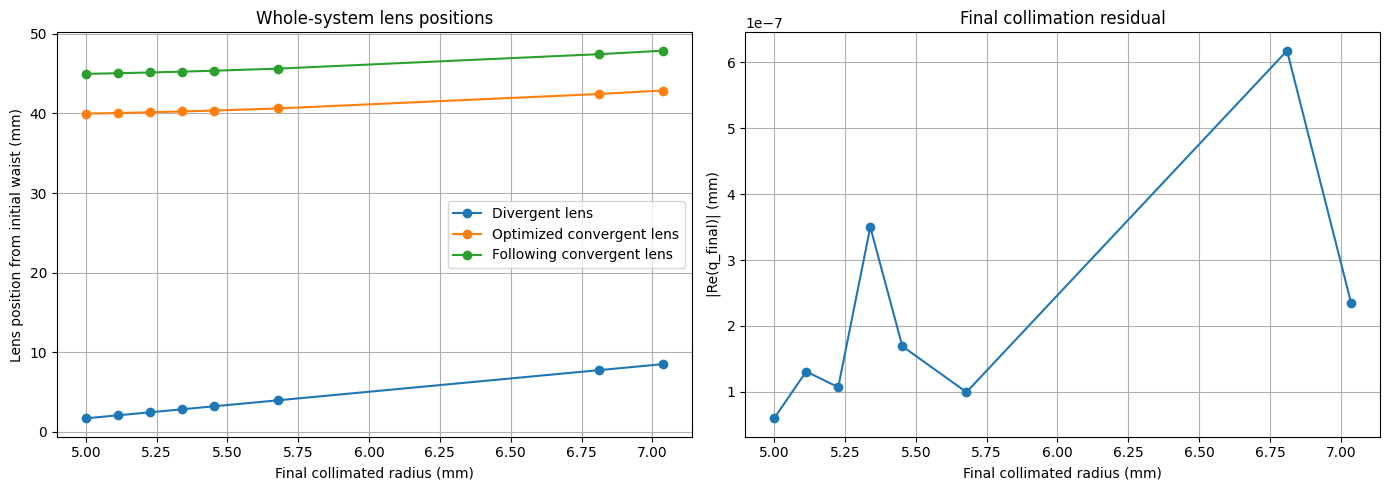

In [49]:
three_lens_designs = design_with_fixed_following_lens(
    collimated_radius_min_mm=5,
    collimated_radius_max_mm=7.150,
    f_divergent_mm=-15.0,
    f_optimized_convergent_mm=50.0,
    following_lens_focal_length_mm=200.0,
    following_lens_distance_mm=5.0,
)